In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [4]:
# from jax import grad, random,vmap,tree_util
# from jax.flatten_util import ravel_pytree

# def init_params(key, d, hidden_dim1,hidden_dim2):
#     rng1, rng2,rng3,rng4,rng5,rng6 = random.split(key,6)
#     params = {
#         'W1': (random.uniform(rng1, (hidden_dim1, d))) * 2.0,
#         'b1': random.normal(rng4, (hidden_dim1,)),
#         'W2': (random.uniform(rng2, (hidden_dim2, hidden_dim1))) * 2.0,
#         'b2': random.normal(rng3, (hidden_dim2,)),
#         'W3' : (random.uniform(rng5, (d, hidden_dim2))) * 2.0,
#         'b3' : random.normal(rng6, (d,))
#     }
#     return params

# @jit
# def forward(params, w):
#     h = jnp.tanh(jnp.dot(params['W1'], w) + params['b1'])  # hidden layer
#     y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
#     return y.squeeze()

In [5]:
# d = 2 
# hidden_dim1 = 5
# hidden_dim2 = 3
# key = random.PRNGKey(0)
# params = init_params(key, d, hidden_dim1, hidden_dim2)  
# flat_params, unravel_fn = ravel_pytree(params)

# def model(theta,W):
#     param = unravel_fn(theta)
#     return vmap(lambda w : forward(param, w))(W)



In [4]:
eta = 0.1
T = 1000
d = 2

VI = VariationalInference(q_0,L,k,d)

# theta0 = flat_params
# W0 = random.normal(random.PRNGKey(2), (1000, d))
# X0 = model(theta0, W0)

key = random.PRNGKey(0)
Theta = VI.run(key,eta,T,d)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(1), (1000, d))
X_fin = VI.model(theta_fin, W_fin)
# X = [NF.model(theta, W0) for theta in Theta]

In [6]:
theta_fin

Array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
        1.8671572,  0.8621924,  1.052346 ,  0.5081084,  1.6217418,
        0.5625129,  1.5363235,  1.0414021,  1.8736734,  0.2349472,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
       -1.2200536,  0.2706675], dtype=float32)

In [7]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(NF.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(T)
# # KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

# for it in range(T):
#     print(it)
#     KGD_fin = KGD_fin.at[it].set(KGD.evaluate(X[it]))
#     # KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
#     # F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
#     # L_fin = L_fin.at[e].set(L(X))
    

In [8]:
# plt.plot(KGD_fin)

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_87275/3228421356.py:23: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


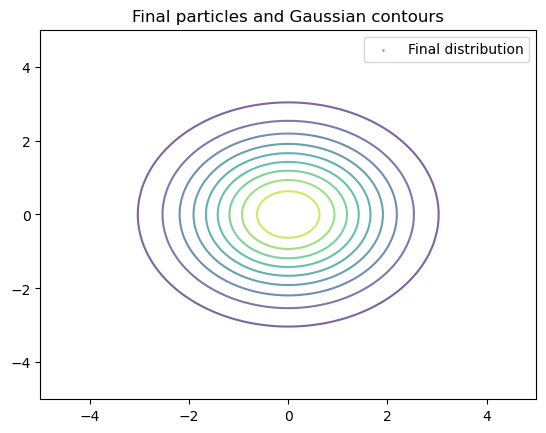

In [5]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=1, alpha=0.5,label='Final distribution')
#plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5,label = 'Initial distribution')
plt.legend()

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))

# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# 
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()